# Exercise 21
**Cristina Correa - 1819211867**


Find another dataset on any of the data hosting websites
(such as UCI or Kaggle) and download it and repeat all the steps on it.

I use Kaggle House Prices - Advanced Regression Techniques data: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

The results aren't very good because of the data complexity and the fact that we don't check if there are outliers


Results for multiple features model:
Mean Absolute Error: 31836.4747
Mean Squared Error: 2325503116.8135
Root Mean Squared Error: 48223.4706
R-squared: 0.2161

Top 10 most correlated features with SalePrice:
OverallQual     0.542911
GrLivArea       0.518393
GarageCars      0.438936
GarageArea      0.432263
TotalBsmtSF     0.428546
1stFlrSF        0.418049
TotRmsAbvGrd    0.392645
FullBath        0.389208
YearBuilt       0.363825
YearRemodAdd    0.354414
dtype: float64


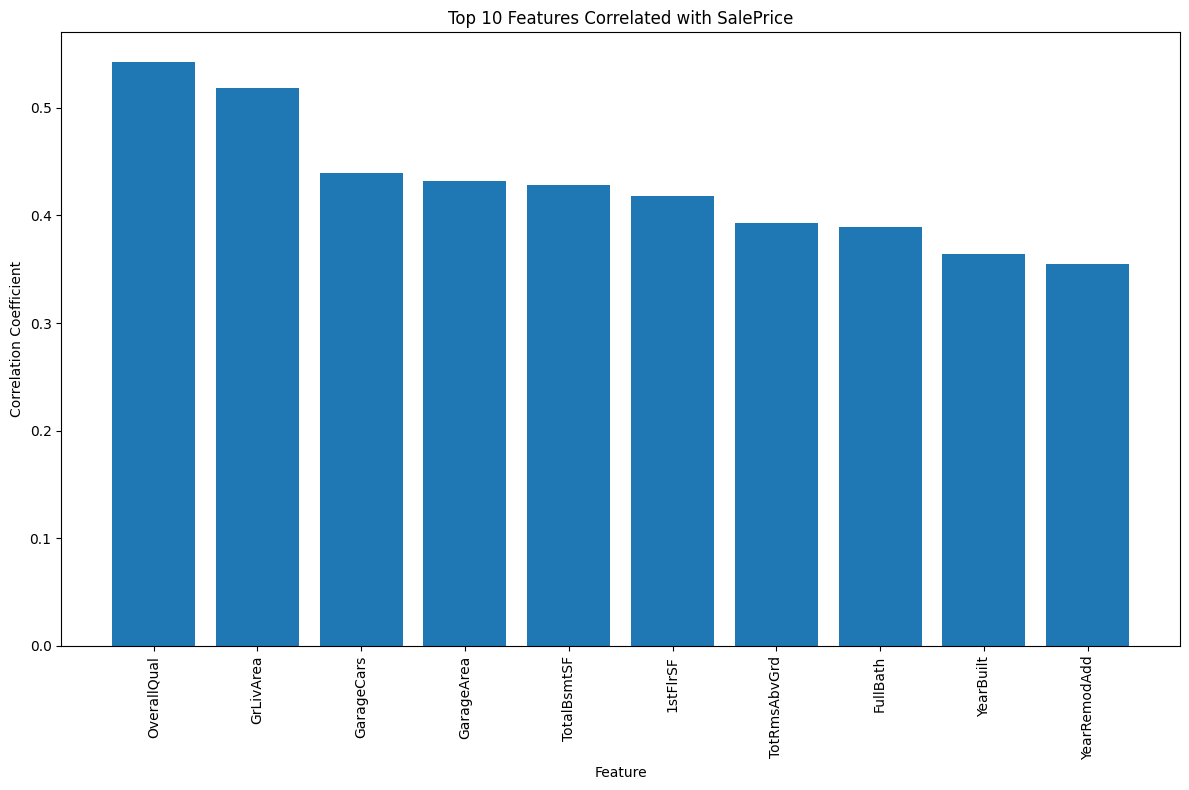

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the training and test data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Combine train and test data for preprocessing
all_data = pd.concat([train_df, test_df], ignore_index=True)

# Handle missing values
numeric_features = all_data.select_dtypes(include=["float64", "int64"]).columns
for col in numeric_features:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# Encode categorical variables
categorical_features = all_data.select_dtypes(include=["object"]).columns
all_data = pd.get_dummies(all_data, columns=categorical_features, drop_first=True)

# Ensure 'SalePrice' is not in test data
all_data = all_data[all_data["SalePrice"].notna()]

# Separate features and target variable
X = all_data.drop(["Id", "SalePrice"], axis=1)
y = all_data["SalePrice"]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nResults for multiple features model:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

# Correlation analysis
correlation_matrix = X.corrwith(y).sort_values(ascending=False)
print("\nTop 10 most correlated features with SalePrice:")
print(correlation_matrix.head(10))

# Visualize top correlations
plt.figure(figsize=(12, 8))
plt.bar(correlation_matrix.index[:10], correlation_matrix.values[:10])
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Feature")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()